In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()
X, y = housing.data, housing.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [5]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
}

In [6]:
print(f"{'模型':<22} {'MSE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"{name:<22} {mse:>8.4f} {rmse:>8.4f} {r2:>8.4f}")

模型                          MSE     RMSE       R²
--------------------------------------------------
LinearRegression         0.5559   0.7456   0.5758
Ridge (alpha=1.0)        0.5559   0.7456   0.5758


In [7]:
import matplotlib.pyplot as plt

In [8]:
model = LinearRegression().fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

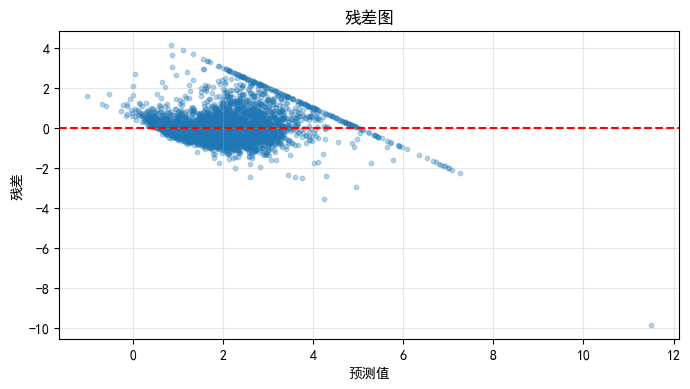

In [11]:
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 4))

plt.scatter(y_pred, y_test - y_pred, alpha=0.3, s=10)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差图')
plt.grid(True, alpha=0.3)

plt.show()